In [174]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [175]:
df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [176]:
y=df['tip']
x=df.drop('tip',axis=1)

In [177]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


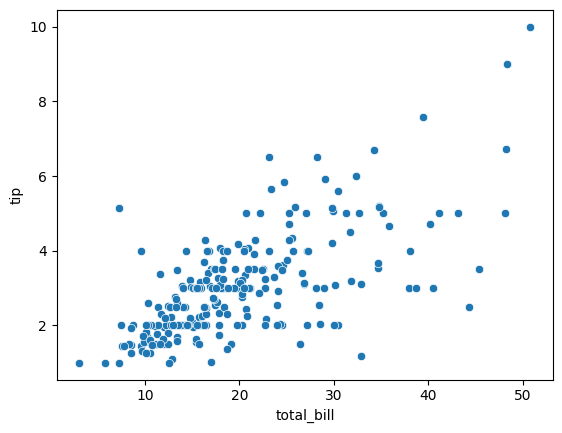

In [178]:
sns.scatterplot(x='total_bill',y='tip',data=df)
plt.show()


<Axes: >

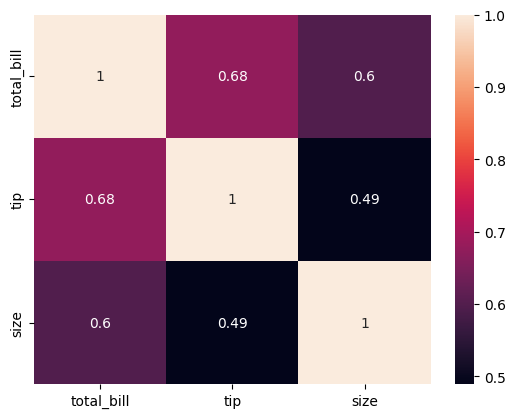

In [179]:
sns.heatmap(df.corr(numeric_only=True),annot=True)



In [180]:
cat_cols=['sex','smoker','day','time']
num_cols=['total_bill','size']

In [181]:
features=['total_bill','size','sex','smoker','day','time']
X=df[features]

In [182]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [183]:
preprocessor=ColumnTransformer([
    ('cat',OneHotEncoder(),cat_cols),
    ('num',StandardScaler(),num_cols)
])
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])


In [184]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['sex', 'smoker', 'day',
                                                   'time']),
                                                 ('num', StandardScaler(),
                                                  ['total_bill', 'size'])])),
                ('model', LinearRegression())])

In [185]:
y_pred=pipeline.predict(X_test)
print("R2 Score:",r2_score(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred))

R2 Score: 0.43730181943482516
RMSE: 0.7033566017436103


In [186]:
import pickle
pickle.dump(pipeline,open('tips_model.pkl','wb'))